In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Titanic Survival Analysis Testing The "Women and Child First" Rule
**Author:** Jennifer Sekyi
**Date:** April 2026

## Overview
This project analyzes the Titanic dataset to identify 
factors that influenced passenger survival rates. 
Key findings:
- Females had significantly higher survival rates than males
- Children had the highest survival rate across age groups
- Seniors had the lowest survival rate
- Random Forest with 100 estimators achieved the best accuracy of 82.12%

## Tools Used
Python, Pandas, Seaborn, Matplotlib, Scikit-learn


In [2]:
train_data = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

# Exploratory Data Analysis

In [3]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train_data. shape

(891, 12)

In [6]:
train_data.columns.to_list()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [7]:
train_data['Age']=train_data['Age'].fillna(train_data['Age'].median())

filled NaN Age values with median Age rather than mean to account for an extreme outliers.

In [8]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
train_data['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [10]:
train_data['Cabin']=train_data['Cabin'].fillna('unknown')

filled NaN cabin values with 'unknown' to preserve the integrity of the dataset instead of dropping them all.

In [11]:
train_data['Cabin']

0      unknown
1          C85
2      unknown
3         C123
4      unknown
        ...   
886    unknown
887        B42
888    unknown
889       C148
890    unknown
Name: Cabin, Length: 891, dtype: object

In [12]:
train_data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [13]:
train_data['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [14]:
train_data['Embarked']=train_data['Embarked'].fillna('S')

In [15]:
train_data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [16]:
train_data['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

# Encoding 

encoded s/c/q to 0/1/2 for scikit-learn model compatability

In [17]:
train_data['Embarked']=train_data['Embarked'].map({'S':0, 'C':1, 'Q':2})

In [18]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,unknown,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,unknown,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,unknown,0


In [19]:
train_data['Sex'].unique()

array(['male', 'female'], dtype=object)

encoded female/male to 0/1 for scikit-learn model compatability

In [20]:
train_data['Sex']=train_data['Sex'].map({'female':0, 'male':1})

In [21]:
train_data['Age']=train_data['Age'].astype(int)

# Visualization

## Survival by Sex

Text(0.5, 1.0, 'Survival by Sex')

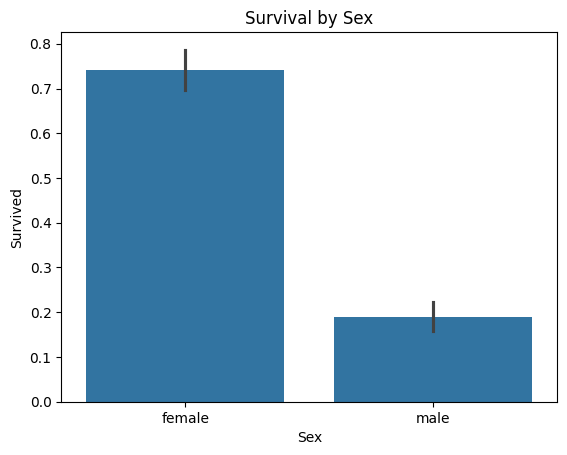

In [22]:
sns.barplot(x='Sex', y= 'Survived',data=train_data)
plt.xticks([0,1],['female','male'])
plt.title('Survival by Sex')

## Survival by Class

Text(0.5, 1.0, 'Survival by Social Class')

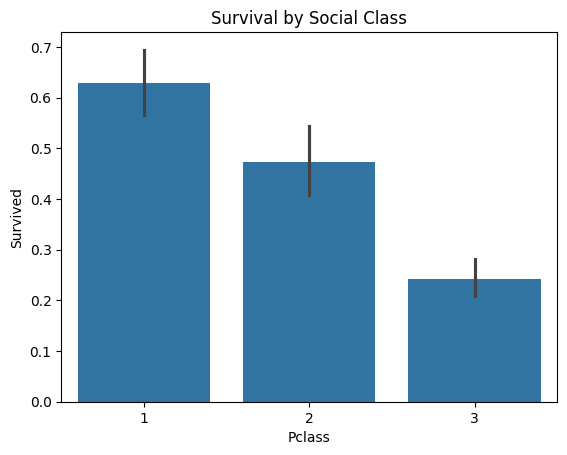

In [23]:
sns.barplot(x ='Pclass', y ='Survived',data=train_data)
plt.title('Survival by Social Class')

## Survival by Age Group

Text(0.5, 1.0, 'Survival by Age Group')

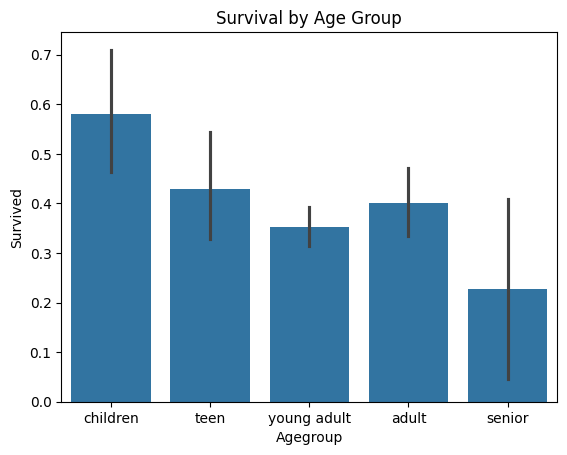

In [24]:
train_data['Agegroup']=pd.cut(train_data['Age'], bins=[-1,12,18,35,60,100], labels=['children','teen','young adult','adult','senior'])
sns.barplot(x='Agegroup', y = 'Survived', data=train_data)
plt.title('Survival by Age Group')

## Heatmap of Titanic Features

In [25]:
corr_matrix=train_data.select_dtypes(include=['number']). corr()

Text(0.5, 1.0, 'heatmap of titanic features')

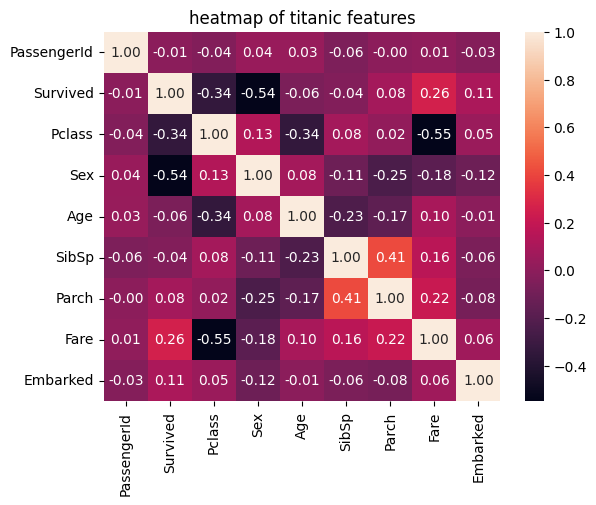

In [26]:
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title('heatmap of titanic features')

# Models

## Logistic Regression Model

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

features=['Pclass', 'Age','Sex','Fare','Embarked']
x=train_data[features]
y=train_data['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(x_train, y_train)
predictions=model.predict(x_test)
score=accuracy_score(y_test,predictions)
print(f"Accuracy score:{score*100:.2f}%")

Accuracy score:79.33%


## Random Forest Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

features=['Pclass', 'Sex', 'Age','Fare', 'Embarked']
x=train_data[features]
y=train_data['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=42)

model=RandomForestClassifier(n_estimators=100, max_depth=5,random_state=42)
model.fit(x_train,y_train)
predictions=model.predict(x_test)
score=accuracy_score(y_test,predictions)
print(f"Accuracy Score:{score*100:.2f}%")


Accuracy Score:82.12%


## Feature Importance

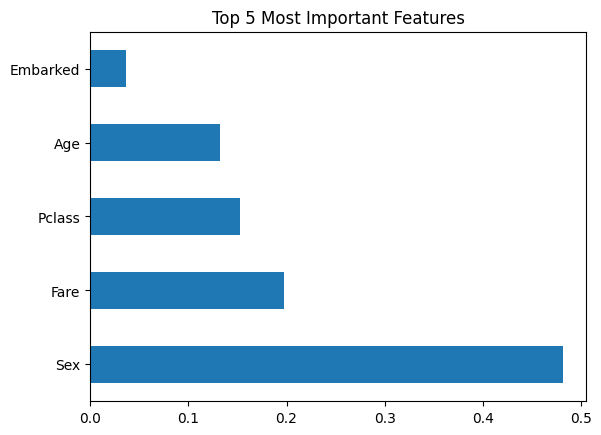

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(
    model.feature_importances_, 
    index=['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
)
feat_importances.nlargest(5).plot(kind='barh')
plt.title('Top 5 Most Important Features')
plt.show()


## Model Comparison and Conclusion

Used two models (Random Forest & Logistic Regression) to predict titanic survival,achieving an accuracy score of 82.12% and 79.33% respectively

Random Forest outperformed logistic regression by 2.8%, likely due to its ability to capture non-linear relationships between features such as age,sex,class and fare

Key Findings
- Gender was the strongest predictor of survival
- Children had the highest survival rate across age groups
- Higher passenger class e.g(1st class) significantly improved survival odds
- Random Forest with 100 estimators achieved the best accuracy